# 03 - Evaluate the Trained Agent
Load the Q-table and measure performance over several episodes.

In [1]:
import gymnasium as gym
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
BINS = (8, 8, 12, 12)
STATE_LIMITS = np.array([2.4, 3.0, 0.2095, 3.5], dtype=np.float32)
model_path = Path('../models/q_table.npy')
q_table = np.load(model_path)
print('Loaded model:', q_table.shape)

Loaded model: (8, 8, 12, 12, 2)


In [3]:
def discretize(observation):
    clipped = np.clip(observation, -STATE_LIMITS, STATE_LIMITS)
    scaled = (clipped + STATE_LIMITS) / (2 * STATE_LIMITS)
    indices = (scaled * np.array(BINS)).astype(int)
    return tuple(np.clip(indices, 0, np.array(BINS)-1))

In [4]:
env = gym.make('CartPole-v1')
rewards = []

In [5]:
for episode in range(20):
    observation, _ = env.reset(seed=1000 + episode)
    total = 0
    for _ in range(500):
        state = discretize(observation)
        action = int(np.argmax(q_table[state]))
        observation, reward, terminated, truncated, _ = env.step(action)
        total += reward
        if terminated or truncated:
            break
    rewards.append(total)

In [6]:
env.close()
print('Episode rewards:', rewards)
print('Average reward:', np.mean(rewards))
print('Best reward:', np.max(rewards))

Episode rewards: [25.0, 28.0, 27.0, 29.0, 74.0, 96.0, 23.0, 27.0, 17.0, 83.0, 87.0, 76.0, 17.0, 27.0, 42.0, 22.0, 86.0, 33.0, 26.0, 22.0]
Average reward: 43.35
Best reward: 96.0


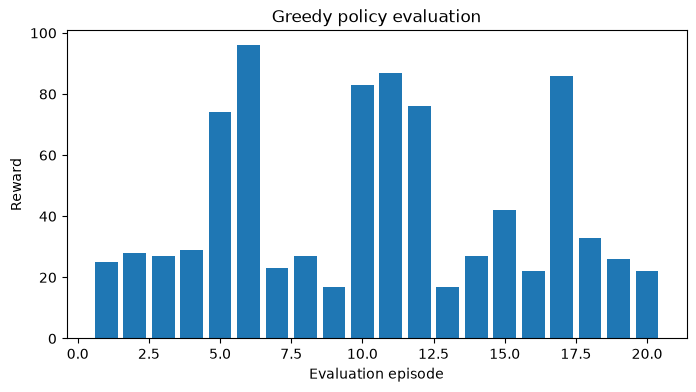

In [7]:
plt.figure(figsize=(8,4))
plt.bar(range(1, len(rewards)+1), rewards)
plt.xlabel('Evaluation episode')
plt.ylabel('Reward')
plt.title('Greedy policy evaluation')
plt.show()

## What to discuss in an interview
Explain why continuous observations were discretized, how epsilon-greedy exploration works, why the discount factor matters, and why evaluation uses the greedy action instead of random exploration.